# Examen Parcial P1 -- Clasificacion de Llantas Danadas
**Redes Neuronales y Aprendizaje Profundo -- Prof. Aldo Camargo**

Ejecuta el pipeline completo usando `src/main.py` (comando unico exigido por el profesor).  
**Instrucciones:** `Runtime -> Run all` (requiere GPU T4, ~35 min).


In [12]:
# CELDA 1: Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')
from pathlib import Path

# Ruta donde subiste la carpeta en Google Drive
PROJECT_DIR = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')
assert PROJECT_DIR.exists(), f'No se encontro {PROJECT_DIR}'
print('Drive montado. Proyecto en:', PROJECT_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive montado. Proyecto en: /content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1


In [13]:
# CELDA 1b: Limpiar resultados de ejecuciones anteriores (garantiza coherencia)
from pathlib import Path
PROJECT_DIR = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')

for f in ['metrics_runs.json', 'metrics_run.json']:
    p = PROJECT_DIR / f
    if p.exists():
        p.unlink()
        print(f'Eliminado: {f}')

import shutil
runs_bak = PROJECT_DIR / 'figures_prev'
figs_dir = PROJECT_DIR / 'figures'
if figs_dir.exists():
    shutil.copytree(str(figs_dir), str(runs_bak), dirs_exist_ok=True)
    print('Figuras anteriores respaldadas en figures_prev/')

print('Listo para ejecucion limpia.')


Eliminado: metrics_run.json
Figuras anteriores respaldadas en figures_prev/
Listo para ejecucion limpia.


In [14]:
# CELDA 2: Instalar dependencias
import subprocess, sys
pkgs = ['torch', 'torchvision', 'PyYAML>=6.0', 'scikit-learn',
        'opencv-python-headless', 'kaggle', 'pandas', 'matplotlib',
        'seaborn', 'Pillow', 'numpy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('Dependencias instaladas.')


Dependencias instaladas.


In [15]:
# CELDA 3: Configurar Kaggle API y descargar dataset (~750 MB)
import os, shutil
from pathlib import Path

kaggle_src = Path('/content/drive/MyDrive/MyDrive_parcial_redes/kaggle.json')
kaggle_dst = Path('/root/.kaggle/kaggle.json')
kaggle_dst.parent.mkdir(exist_ok=True)
if kaggle_src.exists():
    shutil.copy(kaggle_src, kaggle_dst)
    kaggle_dst.chmod(0o600)
    print('kaggle.json configurado.')
else:
    raise FileNotFoundError('Sube kaggle.json a la raiz de tu Google Drive.')

DATASET_DIR = Path('/content/tire_data')
if not DATASET_DIR.exists():
    print('Descargando dataset...')
    os.system('kaggle datasets download -d jehanbhathena/tire-texture-image-recognition -p /content/tire_data --unzip -q')
    print('Dataset listo.')
else:
    print('Dataset ya presente.')

TIRE_TF = DATASET_DIR / 'Tire Textures'
for split in ['training_data', 'testing_data']:
    n = sum(1 for p in (TIRE_TF / split).rglob('*') if p.is_file())
    print(f'  {split}: {n} imagenes')


kaggle.json configurado.
Dataset ya presente.
  training_data: 703 imagenes
  testing_data: 325 imagenes


In [16]:
# CELDA 4: Verificar GPU
import torch
print('GPU disponible:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('Dispositivo   :', torch.cuda.get_device_name(0))
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM          : {vram:.1f} GB')
else:
    print('SIN GPU. Ve a Runtime > Change runtime type > GPU T4.')


GPU disponible: True
Dispositivo   : Tesla T4
VRAM          : 15.6 GB


## Baseline -- ResNet-50 + BCE + Augmentation completa

Comando unico exigido por el profesor (FASE 5 del enunciado):
```bash
python src/main.py --config configs/config_baseline.yaml --data_dir '/content/tire_data/Tire Textures'
```


In [17]:
# CELDA 5: BASELINE ResNet-50 + BCE + Augmentation
import subprocess, sys
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')
DATA_DIR    = '/content/tire_data/Tire Textures'
MAIN_PY     = str(PROJECT_DIR / 'src' / 'main.py')

result = subprocess.run(
    [sys.executable, MAIN_PY,
     '--config', str(PROJECT_DIR / 'configs' / 'config_baseline.yaml'),
     '--data_dir', DATA_DIR],
    cwd=str(PROJECT_DIR))
print('Exit code:', result.returncode)


Exit code: 0


## Estudio de Ablacion (3 variantes requeridas por el profesor)

| # | Config | Factor cambiado vs. baseline |
|---|--------|------------------------------|
| 1 | config_ablation_focal.yaml   | Focal Loss (gamma=2) en lugar de BCE |
| 2 | config_ablation_noaug.yaml   | Sin data augmentation |
| 3 | config_ablation_scratch.yaml | TireCNN desde cero (sin Transfer Learning) |


In [18]:
# CELDA 6: ABLACION 1 -- Focal Loss (gamma=2, alpha=0.5)
result = subprocess.run(
    [sys.executable, MAIN_PY,
     '--config', str(PROJECT_DIR / 'configs' / 'config_ablation_focal.yaml'),
     '--data_dir', DATA_DIR],
    cwd=str(PROJECT_DIR))
print('Ablacion 1 (Focal Loss) -- Exit code:', result.returncode)


Ablacion 1 (Focal Loss) -- Exit code: 0


In [19]:
# CELDA 7: ABLACION 2 -- Sin data augmentation
result = subprocess.run(
    [sys.executable, MAIN_PY,
     '--config', str(PROJECT_DIR / 'configs' / 'config_ablation_noaug.yaml'),
     '--data_dir', DATA_DIR],
    cwd=str(PROJECT_DIR))
print('Ablacion 2 (sin aug) -- Exit code:', result.returncode)


Ablacion 2 (sin aug) -- Exit code: 0


In [20]:
# CELDA 8: ABLACION 3 -- TireCNN desde cero (sin Transfer Learning)
result = subprocess.run(
    [sys.executable, MAIN_PY,
     '--config', str(PROJECT_DIR / 'configs' / 'config_ablation_scratch.yaml'),
     '--data_dir', DATA_DIR],
    cwd=str(PROJECT_DIR))
print('Ablacion 3 (CNN scratch) -- Exit code:', result.returncode)


Ablacion 3 (CNN scratch) -- Exit code: 0


## Resultados y figuras para el informe


In [21]:
# CELDA 9: Tabla resumen de metricas (metrics.json)
import json, pandas as pd
from pathlib import Path

PROJECT_DIR  = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')
metrics_path = PROJECT_DIR / 'metrics.json'
if metrics_path.exists():
    with open(metrics_path) as f:
        m = json.load(f)
    rows = []
    for key, val in m.items():
        if isinstance(val, dict) and 'f1' in val:
            rows.append({'Modelo': key,
                         **{k: round(v, 4) for k, v in val.items() if isinstance(v, float)}})
    if rows:
        display(pd.DataFrame(rows))
    else:
        print('Estructura inesperada en metrics.json.')
else:
    print('metrics.json no encontrado. Ejecuta primero el baseline.')


metrics.json no encontrado. Ejecuta primero el baseline.


Figuras encontradas: 17


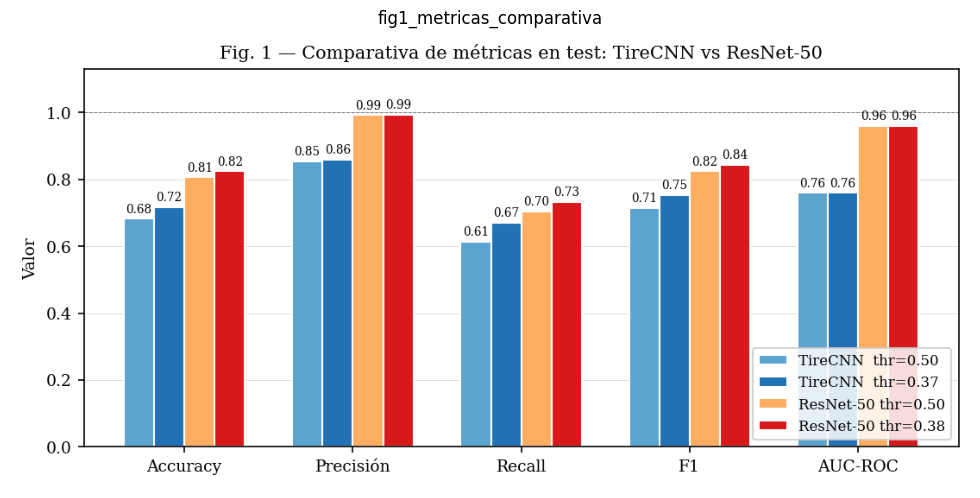

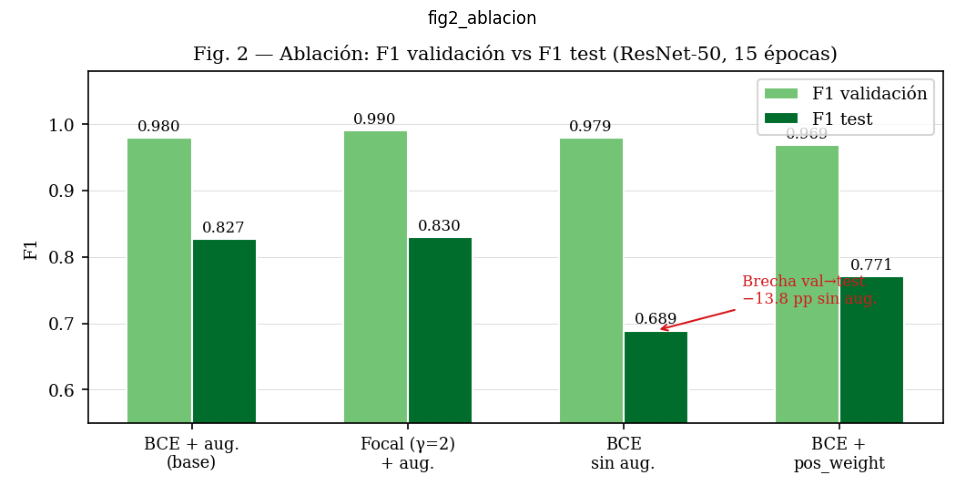

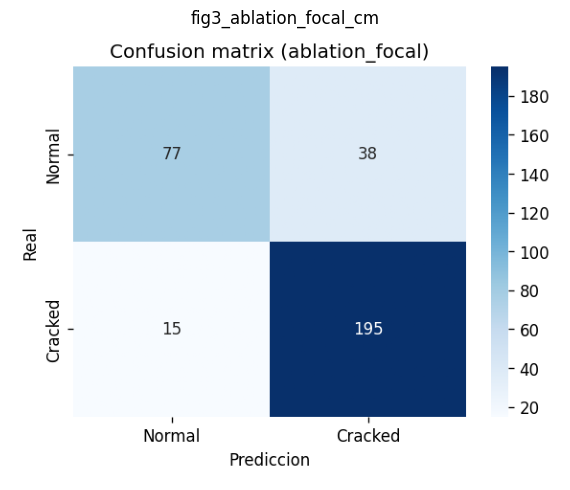

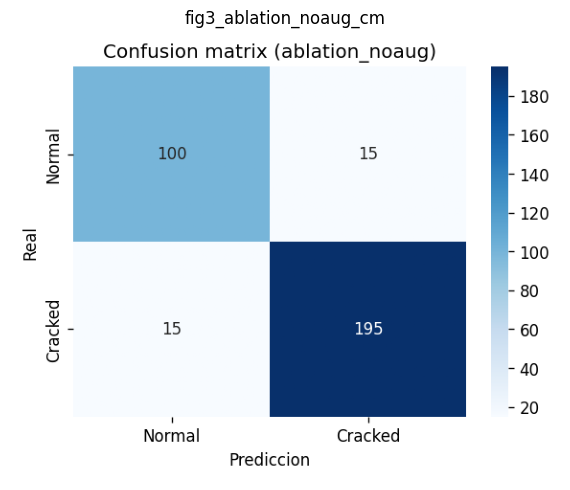

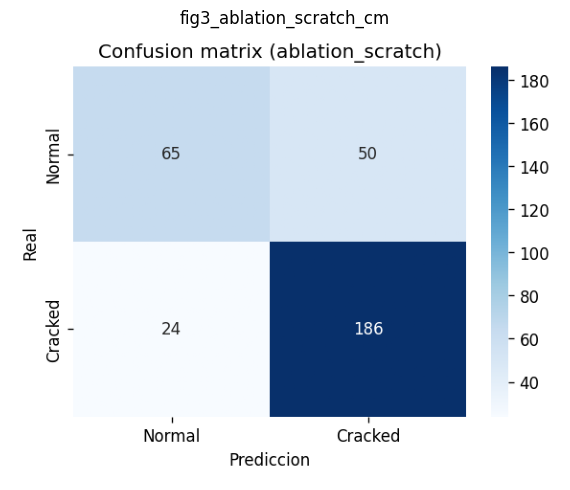

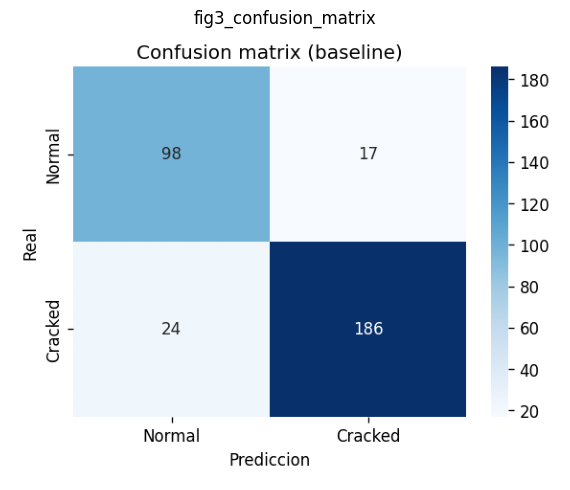

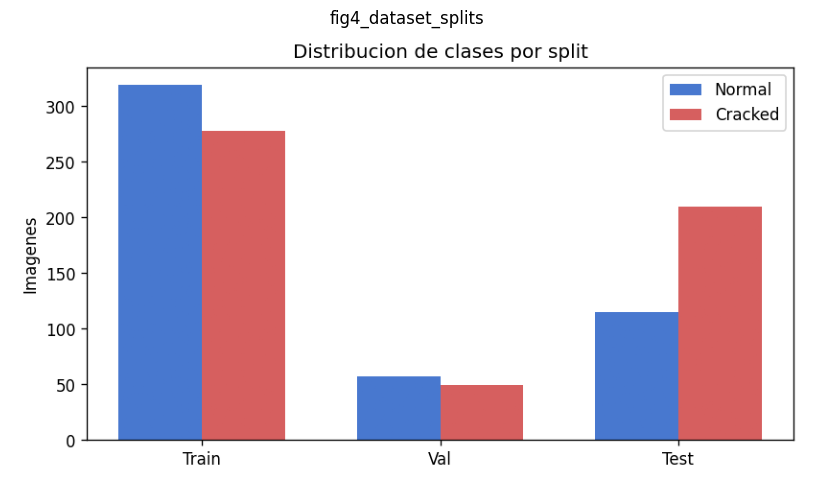

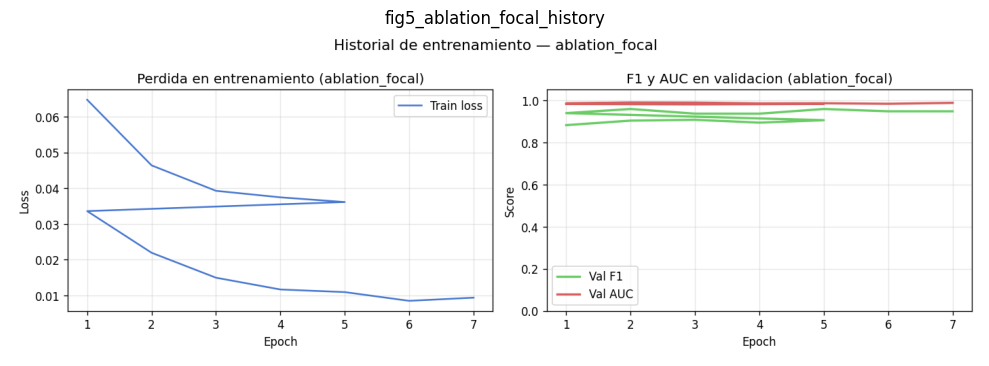

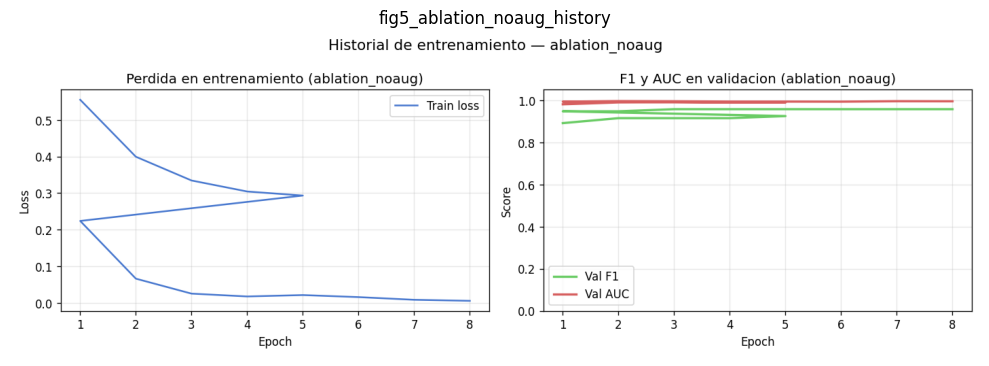

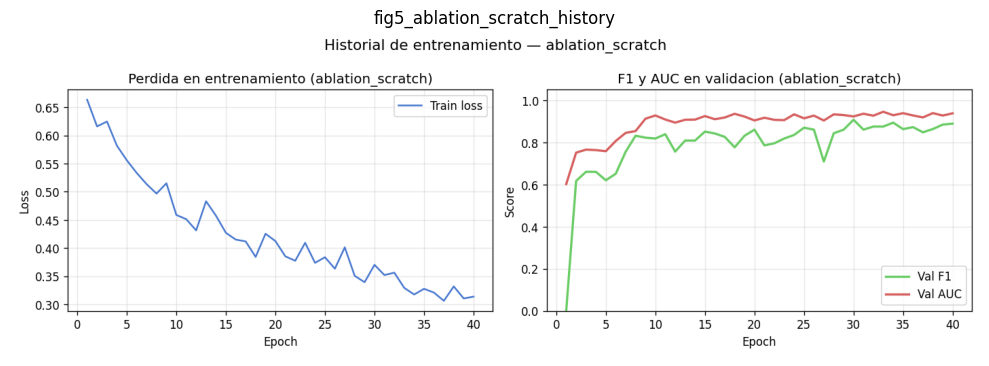

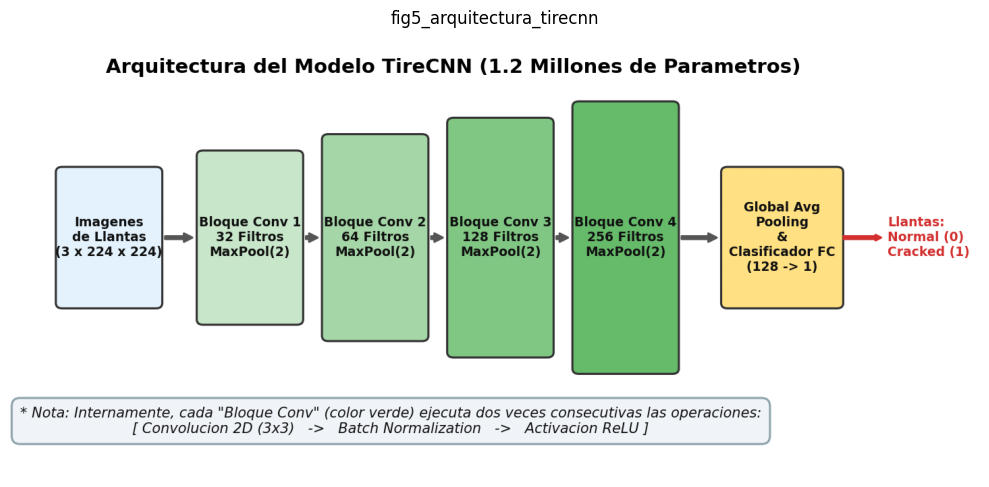

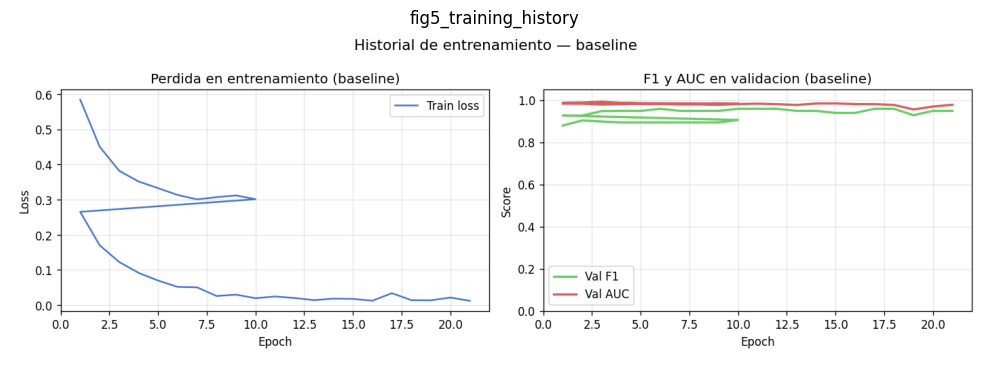

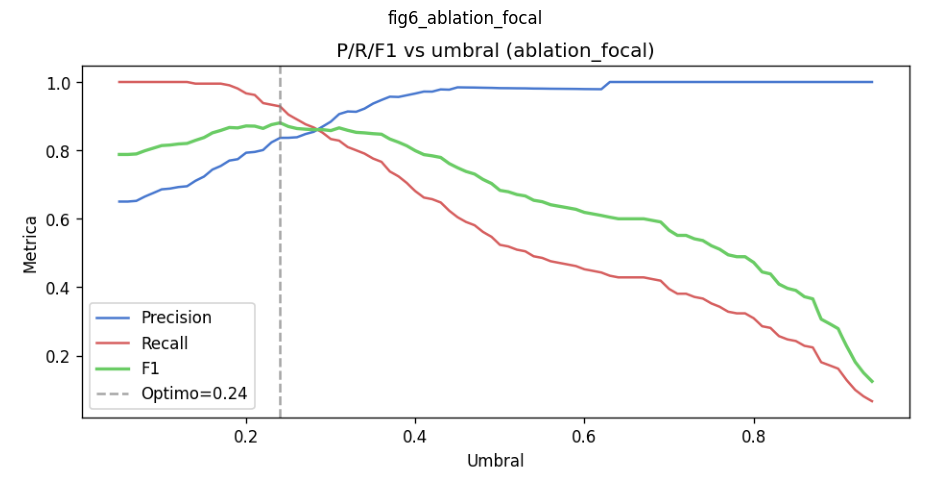

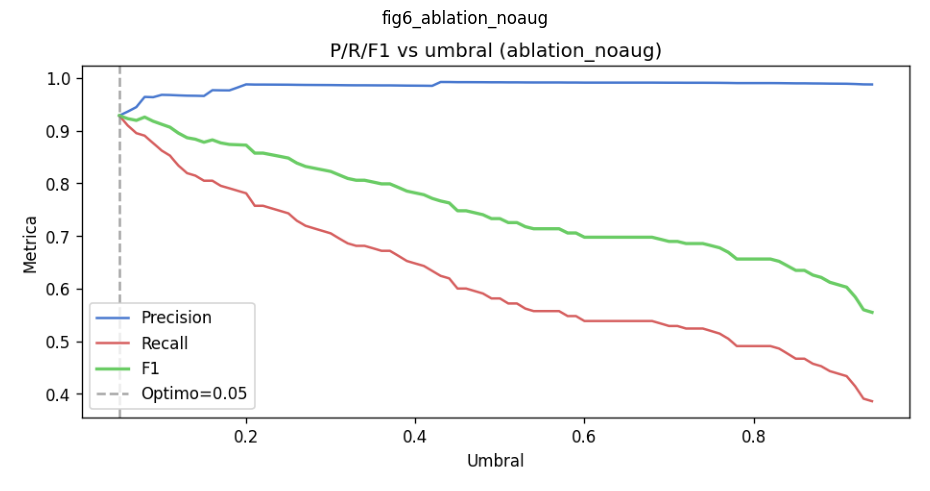

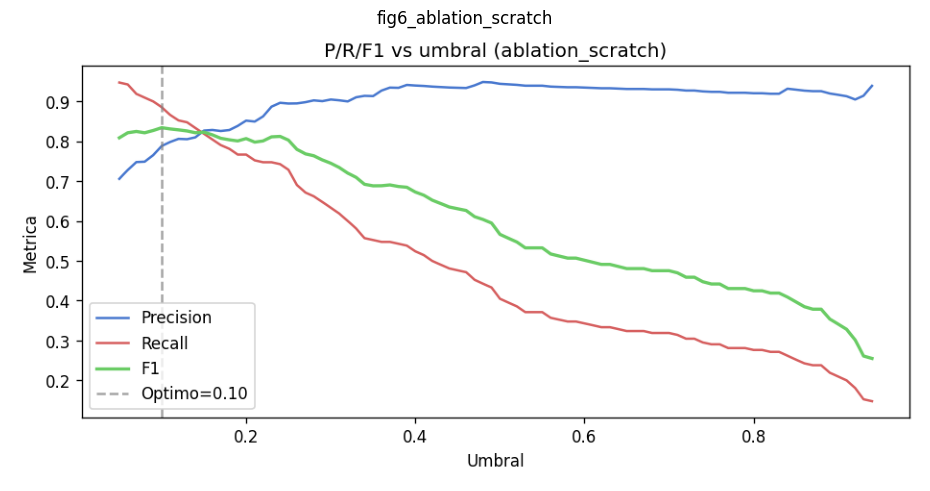

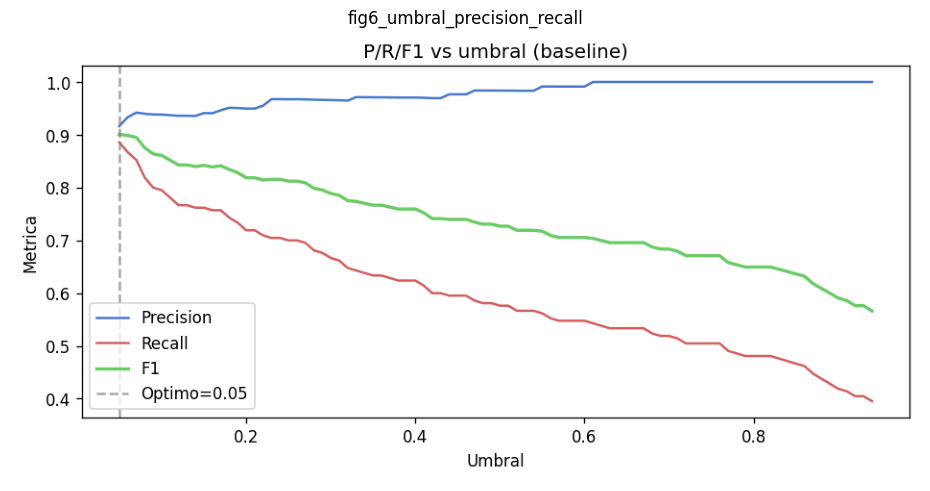

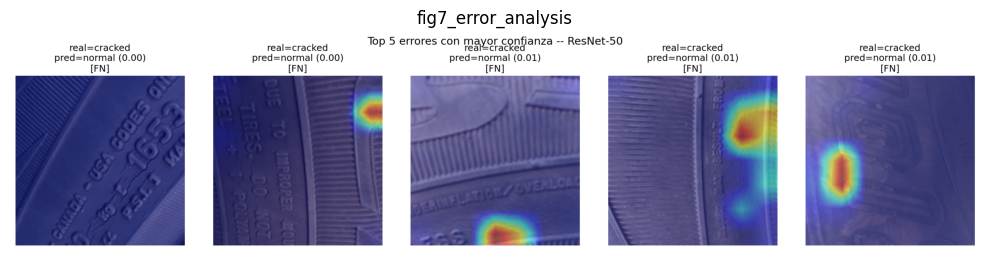

In [22]:
# CELDA 10: Mostrar figuras fig1-fig7
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

FIGURES_DIR = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1/figures')
figs = sorted(FIGURES_DIR.glob('fig*.png'))
print('Figuras encontradas:', len(figs))
for fig_path in figs:
    img = mpimg.imread(str(fig_path))
    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    plt.title(fig_path.stem)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [23]:
# CELDA 11: Verificar checkpoints y outputs generados
from pathlib import Path
PROJECT_DIR = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')

print('=== Checkpoints ===')
for f in sorted((PROJECT_DIR / 'checkpoints').glob('*.pt')):
    mb = f.stat().st_size / 1e6
    print(f'  {f.name}  ({mb:.1f} MB)')

print('\n=== Error analysis outputs ===')
err_dir = PROJECT_DIR / 'outputs' / 'errors'
if err_dir.exists():
    for f in sorted(err_dir.rglob('*')):
        if f.is_file():
            print('  ' + str(f.relative_to(PROJECT_DIR)))
else:
    print('  (no generado -- asegurate que run_error_analysis: true en config_baseline.yaml)')


=== Checkpoints ===
  resnet50.pt  (94.4 MB)
  resnet50_focal.pt  (94.4 MB)
  resnet50_noaug.pt  (94.4 MB)
  tirecnn.pt  (4.8 MB)
  tirecnn_scratch.pt  (4.9 MB)

=== Error analysis outputs ===
  outputs/errors/error_log.csv
  outputs/errors/false_negatives/fn_prob0.002_IMG_4417.jpg
  outputs/errors/false_negatives/fn_prob0.004_IMG_4492.jpg
  outputs/errors/false_negatives/fn_prob0.006_IMG_4475.jpg
  outputs/errors/false_negatives/fn_prob0.006_IMG_4476.jpg
  outputs/errors/false_negatives/fn_prob0.008_IMG_4283.jpg
  outputs/errors/false_positives/fp_prob0.542_Normal-28.jpg
  outputs/errors/false_positives/fp_prob0.600_Untitled-9.jpg


In [24]:
# CELDA FINAL: Generar figuras comparativas (fig1 y fig2) desde esta ejecucion
# Debe ejecutarse DESPUES de que todos los runs anteriores hayan completado
import subprocess, sys
from pathlib import Path

PROJECT_DIR = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')
REPORT_PY   = str(PROJECT_DIR / 'src' / 'report.py')

result = subprocess.run(
    [sys.executable, REPORT_PY, '--work_dir', str(PROJECT_DIR)],
    cwd=str(PROJECT_DIR))
print(f'report.py -- Exit code: {result.returncode}')

print('\n=== Figuras generadas ===')
for f in sorted((PROJECT_DIR / 'figures').glob('*.png')):
    print(f'  {f.name}  ({f.stat().st_size / 1024:.0f} KB)')


report.py -- Exit code: 0

=== Figuras generadas ===
  fig1_metricas_comparativa.png  (42 KB)
  fig2_ablacion.png  (33 KB)
  fig3_ablation_focal_cm.png  (27 KB)
  fig3_ablation_noaug_cm.png  (27 KB)
  fig3_ablation_scratch_cm.png  (27 KB)
  fig3_confusion_matrix.png  (26 KB)
  fig4_dataset_splits.png  (21 KB)
  fig5_ablation_focal_history.png  (62 KB)
  fig5_ablation_noaug_history.png  (58 KB)
  fig5_ablation_scratch_history.png  (85 KB)
  fig5_arquitectura_tirecnn.png  (101 KB)
  fig5_training_history.png  (63 KB)
  fig6_ablation_focal.png  (52 KB)
  fig6_ablation_noaug.png  (49 KB)
  fig6_ablation_scratch.png  (56 KB)
  fig6_umbral_precision_recall.png  (47 KB)
  fig7_error_analysis.png  (1029 KB)


In [25]:
# CELDA INFORME: Tablas Markdown con los valores reales de ESTA ejecucion
# Copia el output de esta celda al informe_pregunta_1.md
import subprocess, sys
from pathlib import Path

PROJECT_DIR    = Path('/content/drive/MyDrive/MyDrive_parcial_redes/Parcial_Parte_1')
TABLES_PY      = str(PROJECT_DIR / 'src' / 'report_tables.py')

result = subprocess.run(
    [sys.executable, TABLES_PY, '--work_dir', str(PROJECT_DIR)],
    cwd=str(PROJECT_DIR), capture_output=True, text=True)
print(result.stdout)
if result.stderr:
    print("STDERR:", result.stderr[:500])



──────────────────────────────────────────────────────────────────────

### Valores clave para la discusión del informe

**TireCNN**
  - F1 (thr=0.50) = 0.567 | AUC = 0.832
  - F1 (thr=0.10) = 0.834 | AUC = 0.832
  - Accuracy=0.772 | Precision=0.788 | Recall=0.886
**ResNet-50**
  - F1 (thr=0.50) = 0.727 | AUC = 0.942
  - F1 (thr=0.05) = 0.901 | AUC = 0.942
  - Accuracy=0.874 | Precision=0.916 | Recall=0.886

──────────────────────────────────────────────────────────────────────

### Tabla 4.1 — Resultados en test

| Modelo | Umbral | Accuracy | Precisión | Recall | F1 | AUC-ROC |
| --- | --- | --- | --- | --- | --- | --- |
| TireCNN (1.2 M params) | 0.50 | 0.600 | 0.944 | 0.405 | 0.567 | 0.832 |
| TireCNN (1.2 M params) | 0.10 | 0.772 | 0.788 | 0.886 | 0.834 | 0.832 |
| ResNet-50 FT (22 M entren.) | 0.50 | 0.720 | 0.984 | 0.576 | 0.727 | 0.942 |
| ResNet-50 FT (22 M entren.) | 0.05 | 0.874 | 0.916 | 0.886 | 0.901 | 0.942 |

─────────────────────────────────────────────────────────────